# 比较、掩码与布尔逻辑



本章讨论了使用布尔掩码来检查和操作NumPy数组中的值。

当您希望根据某些标准提取、修改、计数或以其他方式操作数组中的值时，就会涉及到掩码。例如，您可能希望计算所有大于某个特定值的值，或者删除所有超过某个阈值的异常值。

在NumPy中，布尔掩码通常是完成这些任务最有效的方法。

## 示例：计算雨天数量

假设您拥有一系列数据，表示某个城市一年中每天的降水量。

例如，在这里我们将使用Pandas加载2015年西雅图市的每日降雨统计数据（请参见[第3部分](03.00-Introduction-to-Pandas.ipynb)）。

In [1]:
!pip install vega_datasets

In [2]:
import numpy as np
from vega_datasets import data

# Use DataFrame operations to extract rainfall as a NumPy array
rainfall_mm = np.array(
    data.seattle_weather().set_index('date')['precipitation']['2015'])
len(rainfall_mm)

365

该数组包含365个值，表示2015年1月1日至12月31日的每日降雨量（单位：毫米）。

作为首次快速可视化，我们来看一下下图中显示的降雨天数直方图，该图是使用Matplotlib生成的（我们将在[第4部分](04.00-Introduction-To-Matplotlib.ipynb)中更全面地探讨这个工具）。

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

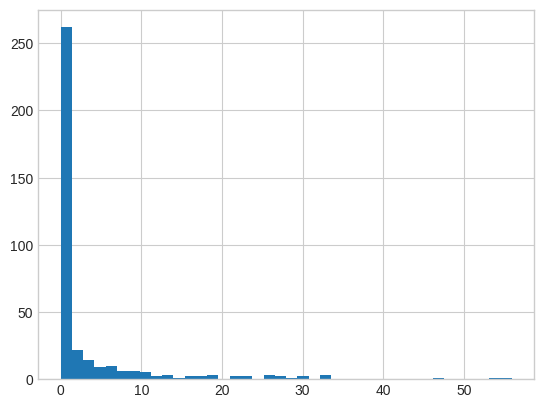

In [4]:
plt.hist(rainfall_mm, 40);

这个直方图给我们提供了数据大致情况的概念：尽管这座城市以多雨而闻名，但在2015年，西雅图的大多数日子几乎没有测量到降雨。

然而，这并未有效传达我们希望看到的一些信息：例如，今年有多少个雨天？这些雨天的平均降水量是多少？有多少天降水超过10毫米？

一种方法是手动回答这些问题：我们可以遍历数据，每当看到某个期望范围内的值时，就增加一个计数器。

但正如本章所讨论的那样，这种方法在编写代码和计算结果方面都非常低效。

我们在[NumPy数组上的计算：通用函数](02.03-Computation-on-arrays-ufuncs.ipynb)中看到，NumPy的ufuncs可以替代循环，以快速进行数组上的逐元素算术运算；同样，我们也可以使用其他ufuncs对数组进行逐元素*比较*，然后操纵结果来回答我们的提问。

现在我们暂且不谈数据，而是讨论一些NumPy中的通用工具，以利用*掩码*快速回答这些类型的问题。

## 比较运算符作为通用函数

[NumPy数组上的计算：通用函数](02.03-Computation-on-arrays-ufuncs.ipynb)介绍了通用函数，并特别关注了算术运算符。我们看到，使用 `+`、`-`、`*`、`/` 和其他运算符对数组进行操作时，会导致逐元素的操作。

NumPy还实现了比较运算符，例如 `<`（小于）和 `>`（大于），这些也是逐元素的通用函数。

这些比较运算符的结果始终是一个布尔数据类型的数组。

所有六种标准比较操作均可使用。

In [5]:
x = np.array([1, 2, 3, 4, 5])

In [10]:
x < 3  # less than

array([ True,  True, False, False, False])

In [11]:
x > 3  # greater than

array([False, False, False,  True,  True])

In [12]:
x <= 3  # less than or equal

array([ True,  True,  True, False, False])

In [13]:
x >= 3  # greater than or equal

array([False, False,  True,  True,  True])

In [14]:
x != 3  # not equal

array([ True,  True, False,  True,  True])

In [15]:
x == 3  # equal

array([False, False,  True, False, False])

可以对两个数组进行逐元素比较，并包含复合表达式：

In [16]:
(2 * x) == (x ** 2)

array([False,  True, False, False, False])

与算术运算符类似，比较运算符在NumPy中也作为ufuncs实现；例如，当你写`x < 3`时，NumPy内部使用的是`np.less(x, 3)`。

以下是比较运算符及其等效ufuncs的总结：

| Operator    | Equivalent ufunc  | Operator   | Equivalent ufunc |
|-------------|-------------------|------------|------------------|
|`==`         |`np.equal`         |`!=`        |`np.not_equal`    |
|`<`          |`np.less`          |`<=`        |`np.less_equal`   |
|`>`          |`np.greater`       |`>=`        |`np.greater_equal`|

正如算术 ufuncs 的情况一样，这些函数可以作用于任何大小和形状的数组。

以下是一个二维示例：

In [17]:
rng = np.random.default_rng(seed=1701)
x = rng.integers(10, size=(3, 4))
x

array([[9, 4, 0, 3],
       [8, 6, 3, 1],
       [3, 7, 4, 0]])

In [18]:
x < 6

array([[False,  True,  True,  True],
       [False, False,  True,  True],
       [ True, False,  True,  True]])

在每种情况下，结果都是一个布尔数组，而NumPy提供了多种简单的模式来处理这些布尔结果。

## 使用布尔数组

给定一个布尔数组，可以进行许多有用的操作。

我们将使用 `x`，这是我们之前创建的二维数组。

In [22]:
print(x)

[[9 4 0 3]
 [8 6 3 1]
 [3 7 4 0]]


### 计数条目

要计算布尔数组中 `True` 条目的数量，可以使用 `np.count_nonzero`。

In [23]:
# how many values less than 6?
np.count_nonzero(x < 6)

np.int64(8)

我们看到有八个数组元素小于6。

获取这些信息的另一种方法是使用 `np.sum`；在这种情况下，`False` 被解释为 `0`，而 `True` 被解释为 `1`。

In [24]:
np.sum(x < 6)

np.int64(8)

`np.sum` 的优点在于，与其他 NumPy 聚合函数一样，这个求和操作可以沿着行或列进行。

修改建议：
1. 将英文翻译为中文，确保语义准确。
2. 简化句子结构，使其更加清晰易懂。

In [25]:
# how many values less than 6 in each row?
np.sum(x < 6, axis=1)

array([3, 2, 3])

这段文本统计了矩阵中每一行小于6的值的数量。

如果我们想快速检查是否有任何或所有值为`True`，可以使用（你猜对了）`np.any`或`np.all`:

In [26]:
# are there any values greater than 8?
np.any(x > 8)

np.True_

In [27]:
# are there any values less than zero?
np.any(x < 0)

np.False_

In [28]:
# are all values less than 10?
np.all(x < 10)

np.True_

In [29]:
# are all values equal to 6?
np.all(x == 6)

np.False_

`np.all` 和 `np.any` 也可以沿特定轴使用。例如：

In [30]:
# are all values in each row less than 8?
np.all(x < 8, axis=1)

array([False, False,  True])

在这里，第三行的所有元素都小于8，而其他行则不是这样。

最后，给出一个简短的警告：正如在[聚合：最小值、最大值及其间的一切](02.04-Computation-on-arrays-aggregates.ipynb)中提到的，Python内置了`sum`、`any`和`all`函数。这些函数与NumPy版本的语法不同，特别是在处理多维数组时会失败或产生意想不到的结果。请确保在这些示例中使用`np.sum`、`np.any`和 `np.all`！

### 布尔运算符

我们已经看到如何统计所有降雨量少于20毫米的天数，或所有降雨量超过10毫米的天数。

但是，如果我们想知道有多少天的降雨量在10毫米以上且在20毫米以下呢？我们可以使用Python的*按位逻辑运算符* `&`、`|`、`^` 和 `~` 来实现这一点。

与标准算术运算符一样，NumPy将这些运算符重载为ufuncs，可以逐元素地作用于（通常是布尔）数组。

例如，我们可以如下处理这种复合问题：

In [31]:
np.sum((rainfall_mm > 10) & (rainfall_mm < 20))

np.int64(16)

这告诉我们，有16天的降雨量在10到20毫米之间。

这里的括号非常重要。由于运算符优先级规则，如果去掉括号，该表达式将被如下评估，这会导致错误：

``` python
rainfall_mm > (10 & rainfall_mm) < 20
```

让我们演示一个更复杂的表达式。利用德摩根定律，我们可以以不同的方式计算出相同的结果。

In [32]:
np.sum(~( (rainfall_mm <= 10) | (rainfall_mm >= 20) ))

np.int64(16)

结合比较运算符和布尔运算符在数组上的使用，可以实现多种高效的逻辑操作。

下表总结了按位布尔运算符及其等效的ufuncs：

| Operator    | Equivalent ufunc  | Operator    | Equivalent ufunc  |
|-------------|-------------------|-------------|-------------------|
|`&`          |`np.bitwise_and`   |&#124;       |`np.bitwise_or`    |
|`^`          |`np.bitwise_xor`   |`~`          |`np.bitwise_not`   |

使用这些工具，我们可以开始回答关于天气数据的许多问题。

以下是结合掩蔽与聚合时我们可以计算的一些结果示例：

In [33]:
print("Number days without rain:  ", np.sum(rainfall_mm == 0))
print("Number days with rain:     ", np.sum(rainfall_mm != 0))
print("Days with more than 10 mm: ", np.sum(rainfall_mm > 10))
print("Rainy days with < 5 mm:    ", np.sum((rainfall_mm > 0) &
                                            (rainfall_mm < 5)))

Number days without rain:   221
Number days with rain:      144
Days with more than 10 mm:  34
Rainy days with < 5 mm:     83


## 布尔数组作为掩码

在前面的部分，我们直接对布尔数组计算了聚合值。

一种更强大的模式是将布尔数组用作掩码，以选择数据的特定子集。让我们回到之前的 `x` 数组：

In [34]:
x

array([[9, 4, 0, 3],
       [8, 6, 3, 1],
       [3, 7, 4, 0]])

假设我们想要一个包含数组中所有小于5的值的数组。我们可以很容易地为这个条件获得一个布尔数组，正如我们之前所看到的：

In [35]:
x < 5

array([[False,  True,  True,  True],
       [False, False,  True,  True],
       [ True, False,  True,  True]])

现在，为了从数组中*选择*这些值，我们可以简单地对这个布尔数组进行索引；这被称为*掩码*操作。

In [36]:
x[x < 5]

array([4, 0, 3, 3, 1, 3, 4, 0])

What is returned is a one-dimensional array filled with all the values that meet this condition; in other words, all the values in positions at which the mask array is `True`.

We are then free to operate on these values as we wish.
For example, we can compute some relevant statistics on our Seattle rain data:

In [37]:
# construct a mask of all rainy days
rainy = (rainfall_mm > 0)

# construct a mask of all summer days (June 21st is the 172nd day)
days = np.arange(365)
summer = (days > 172) & (days < 262)

print("Median precip on rainy days in 2015 (mm):   ",
      np.median(rainfall_mm[rainy]))
print("Median precip on summer days in 2015 (mm):  ",
      np.median(rainfall_mm[summer]))
print("Maximum precip on summer days in 2015 (mm): ",
      np.max(rainfall_mm[summer]))
print("Median precip on non-summer rainy days (mm):",
      np.median(rainfall_mm[rainy & ~summer]))

Median precip on rainy days in 2015 (mm):    3.8
Median precip on summer days in 2015 (mm):   0.0
Maximum precip on summer days in 2015 (mm):  32.5
Median precip on non-summer rainy days (mm): 4.1


By combining Boolean operations, masking operations, and aggregates, we can very quickly answer these sorts of questions about our dataset.

## Using the Keywords and/or Versus the Operators &/|

One common point of confusion is the difference between the keywords `and` and `or` on the one hand, and the operators `&` and `|` on the other.
When would you use one versus the other?

The difference is this: `and` and `or` operate on the object as a whole, while `&` and `|` operate on the elements within the object.

When you use `and` or `or`, it is equivalent to asking Python to treat the object as a single Boolean entity.
In Python, all nonzero integers will evaluate as `True`. Thus:

In [38]:
bool(42), bool(0)

(True, False)

In [39]:
bool(42 and 0)

False

In [40]:
bool(42 or 0)

True

When you use `&` and `|` on integers, the expression operates on the bitwise representation of the element, applying the *and* or the *or* to the individual bits making up the number:

In [41]:
bin(42)

'0b101010'

In [42]:
bin(59)

'0b111011'

In [43]:
bin(42 & 59)

'0b101010'

In [44]:
bin(42 | 59)

'0b111011'

Notice that the corresponding bits of the binary representation are compared in order to yield the result.

When you have an array of Boolean values in NumPy, this can be thought of as a string of bits where `1 = True` and `0 = False`, and `&` and `|` will operate similarly to in the preceding examples:

In [45]:
A = np.array([1, 0, 1, 0, 1, 0], dtype=bool)
B = np.array([1, 1, 1, 0, 1, 1], dtype=bool)
A | B

array([ True,  True,  True, False,  True,  True])

But if you use `or` on these arrays it will try to evaluate the truth or falsehood of the entire array object, which is not a well-defined value:

In [46]:
A or B

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Similarly, when evaluating a Boolean expression on a given array, you should use `|` or `&` rather than `or` or `and`:

In [47]:
x = np.arange(10)
(x > 4) & (x < 8)

array([False, False, False, False, False,  True,  True,  True, False,
       False])

Trying to evaluate the truth or falsehood of the entire array will give the same `ValueError` we saw previously:

In [48]:
(x > 4) and (x < 8)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

So, remember this: `and` and `or` perform a single Boolean evaluation on an entire object, while `&` and `|` perform multiple Boolean evaluations on the content (the individual bits or bytes) of an object.
For Boolean NumPy arrays, the latter is nearly always the desired operation.